In [5]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from pathlib import Path

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU: NVIDIA RTX A6000


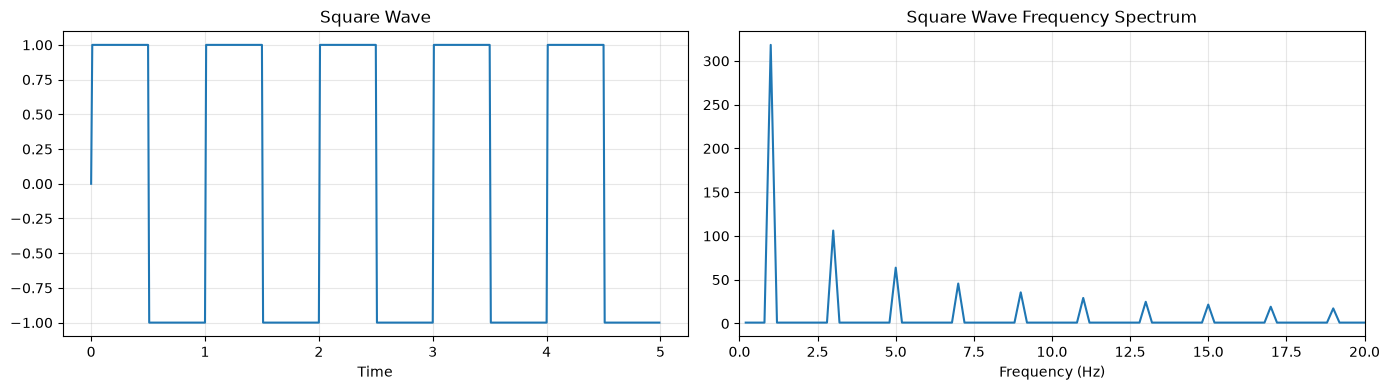

Square wave has energy at odd harmonics: 1, 3, 5, 7, 9... Hz


In [6]:
# %% Cell 2 - Signal generation functions (same as before + square wave)

def normalize_signal(y, y_min=None, y_max=None):
    if y_min is None:
        y_min = y.min()
    if y_max is None:
        y_max = y.max()
    return (y - y_min) / (y_max - y_min), y_min, y_max

def denormalize_signal(y_norm, y_min, y_max):
    return y_norm * (y_max - y_min) + y_min

def discretize(y_norm, precision=3, base=10):
    tokens = []
    for val in y_norm:
        val = np.clip(val, 0, 1 - 1e-9)
        digits = []
        remaining = val
        for _ in range(precision):
            remaining *= base
            digit = int(remaining)
            digits.append(digit)
            remaining -= digit
        tokens.extend(digits)
    return tokens

def undiscretize(tokens, precision=3, base=10):
    values = []
    for i in range(0, len(tokens), precision):
        chunk = tokens[i:i+precision]
        if len(chunk) < precision:
            break
        val = 0
        for j, d in enumerate(chunk):
            val += d / (base ** (j + 1))
        values.append(val)
    return np.array(values)

def generate_square_wave(A, omega, length, dt=0.01):
    """Generate a square wave using the sign of a sine wave."""
    t = np.arange(length) * dt
    y = A * np.sign(np.sin(omega * t))
    return t, y

# Test: visualize and compare with sinusoid
A = 1.0
omega = 2 * np.pi

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Square wave
t, y_square = generate_square_wave(A, omega, 500)
axes[0].plot(t, y_square)
axes[0].set_title('Square Wave')
axes[0].set_xlabel('Time')
axes[0].grid(True, alpha=0.3)

# Its frequency spectrum
from numpy.fft import fft, fftfreq
N = len(y_square)
freqs = fftfreq(N, d=0.01)
spectrum = np.abs(fft(y_square))
mask = freqs > 0
axes[1].plot(freqs[mask], spectrum[mask])
axes[1].set_title('Square Wave Frequency Spectrum')
axes[1].set_xlabel('Frequency (Hz)')
axes[1].set_xlim(0, 20)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Square wave has energy at odd harmonics: 1, 3, 5, 7, 9... Hz")

In [7]:
# %% Cell 3 - Transformer model (adapted for digit tokens)

block_size = 512
batch_size = 16
learning_rate = 0.001
weight_decay = 1e-3
dropout = 0.0
vocab_size = 10
n_head = 4
n_layer = 4
n_embd = 128

class Head(nn.Module):
    def __init__(self, head_size):
        super().__init__()
        self.key = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        B, T, C = x.shape
        k = self.key(x)
        q = self.query(x)
        wei = q @ k.transpose(-2, -1) * C ** -0.5
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float('-inf'))
        wei = F.softmax(wei, dim=-1)
        wei = self.dropout(wei)
        v = self.value(x)
        return wei @ v

class MultiHeadAttention(nn.Module):
    def __init__(self, num_heads, head_size):
        super().__init__()
        self.heads = nn.ModuleList([Head(head_size) for _ in range(num_heads)])
        self.proj = nn.Linear(n_embd, n_embd)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        return self.dropout(self.proj(out))

class FeedForward(nn.Module):
    def __init__(self, n_embd):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.GELU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(dropout),
        )
    def forward(self, x):
        return self.net(x)

class Block(nn.Module):
    def __init__(self, n_embd, n_head):
        super().__init__()
        head_size = n_embd // n_head
        self.sa = MultiHeadAttention(n_head, head_size)
        self.ffwd = FeedForward(n_embd)
        self.ln1 = nn.LayerNorm(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)

    def forward(self, x):
        x = x + self.sa(self.ln1(x))
        x = x + self.ffwd(self.ln2(x))
        return x

class SignalTransformer(nn.Module):
    def __init__(self):
        super().__init__()
        self.token_embedding = nn.Embedding(vocab_size, n_embd)
        self.position_embedding = nn.Embedding(block_size, n_embd)
        self.blocks = nn.Sequential(*[Block(n_embd, n_head) for _ in range(n_layer)])
        self.ln_f = nn.LayerNorm(n_embd)
        self.lm_head = nn.Linear(n_embd, vocab_size)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        tok_emb = self.token_embedding(idx)
        pos_emb = self.position_embedding(torch.arange(T, device=device))
        x = tok_emb + pos_emb
        x = self.blocks(x)
        x = self.ln_f(x)
        logits = self.lm_head(x)
        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape
            logits = logits.view(B * T, C)
            targets = targets.view(B * T)
            loss = F.cross_entropy(logits, targets)
        return logits, loss

    def generate(self, idx, max_new_tokens):
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -block_size:]
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :]
            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, idx_next), dim=1)
        return idx

print("Model defined.")

Model defined.


In [8]:
eval_iters = 200

def get_batch(sequences, split='train'):
    n = int(0.9 * len(sequences))
    data = sequences[:n] if split == 'train' else sequences[n:]
    while True:
        seq_indices = torch.randint(len(data), (batch_size,))
        x_batch, y_batch = [], []
        for idx in seq_indices:
            sequence = data[idx]
            if len(sequence) >= block_size + 1:
                start_idx = torch.randint(0, len(sequence) - block_size, (1,))
                x_batch.append(sequence[start_idx:start_idx + block_size])
                y_batch.append(sequence[start_idx + 1:start_idx + block_size + 1])
        if len(x_batch) > 0:
            return torch.stack(x_batch).to(device), torch.stack(y_batch).to(device)

@torch.no_grad()
def estimate_loss(model, sequences):
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(sequences, split)
            logits, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean()
    model.train()
    return out

print("Helper functions defined.")

Helper functions defined.


In [9]:
A = 1.0
omega = 2 * np.pi

def generate_training_squares(num_signals, signal_length, A, omega, dt=0.01, noise_std=0.0):
    all_tokens = []
    for i in range(num_signals):
        phase = np.random.uniform(0, 2 * np.pi)
        t = np.arange(signal_length) * dt
        y = A * np.sign(np.sin(omega * t + phase))
        if noise_std > 0:
            y += np.random.normal(0, noise_std, signal_length)
        y_range = A + 3 * noise_std if noise_std > 0 else A
        y_norm = (y - (-y_range)) / (2 * y_range)
        y_norm = np.clip(y_norm, 0, 1 - 1e-9)
        tokens = discretize(y_norm)
        all_tokens.append(torch.tensor(tokens, dtype=torch.long))
    return all_tokens, y_range

noise_levels = [0.0, 0.1, 0.2, 0.5, 1.0]
results_square = {}

for sigma in noise_levels:
    print(f"\n{'='*60}")
    print(f"Training with noise sigma = {sigma}")
    print(f"{'='*60}")
    
    signals, y_range = generate_training_squares(500, 256, A, omega, noise_std=sigma)
    
    model = SignalTransformer().to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    
    for iter in range(20000):
        xb, yb = get_batch(signals, 'train')
        logits, loss = model(xb, yb)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()
        
        if iter % 5000 == 0 or iter == 19999:
            losses = estimate_loss(model, signals)
            print(f"  iter {iter}: train {losses['train']:.4f}, val {losses['val']:.4f}")
    
    model.eval()
    t_ctx = np.arange(50) * 0.01
    y_ctx = A * np.sign(np.sin(omega * t_ctx))
    y_ctx_norm = (y_ctx - (-y_range)) / (2 * y_range)
    y_ctx_norm = np.clip(y_ctx_norm, 0, 1 - 1e-9)
    ctx_tokens = discretize(y_ctx_norm)
    ctx_tensor = torch.tensor(ctx_tokens, dtype=torch.long).unsqueeze(0).to(device)
    
    with torch.no_grad():
        gen = model.generate(ctx_tensor, 600)
    
    gen_tokens = gen.tolist()[0]
    gen_values_norm = undiscretize(gen_tokens)
    gen_values = gen_values_norm * (2 * y_range) + (-y_range)
    generated = gen_values[50:]
    
    t_gen = np.arange(len(generated)) * 0.01
    y_true = A * np.sign(np.sin(omega * (t_gen + 0.50)))
    mae = np.mean(np.abs(y_true[:len(generated)] - generated[:len(y_true)]))
    
    results_square[sigma] = {
        'mae': mae,
        'generated': generated,
        'y_true': y_true,
        'train_loss': losses['train'].item(),
        'val_loss': losses['val'].item(),
    }
    
    print(f"  MAE vs clean square wave: {mae:.4f}")
    
    torch.save(model.state_dict(),
               os.path.expanduser(f'~/research-project/models/sinusoid/square_sigma{sigma}.pt'))

print("\n\nAll noise levels complete!")
print(f"\n{'Sigma':<10} {'Train loss':<12} {'Val loss':<12} {'MAE':<10}")
print("-" * 44)
for sigma in noise_levels:
    r = results_square[sigma]
    print(f"{sigma:<10} {r['train_loss']:<12.4f} {r['val_loss']:<12.4f} {r['mae']:<10.4f}")


Training with noise sigma = 0.0
  iter 0: train 0.9342, val 0.9350
  iter 5000: train 0.0182, val 0.0183
  iter 10000: train 0.0108, val 0.0108
  iter 15000: train 0.0103, val 0.0104
  iter 19999: train 0.0099, val 0.0100
  MAE vs clean square wave: 0.0140

Training with noise sigma = 0.1
  iter 0: train 2.2862, val 2.2833
  iter 5000: train 1.7035, val 1.7079
  iter 10000: train 1.3967, val 2.0679
  iter 15000: train 0.9621, val 3.4836
  iter 19999: train 0.8344, val 4.1953
  MAE vs clean square wave: 0.9963

Training with noise sigma = 0.2
  iter 0: train 2.3382, val 2.3396
  iter 5000: train 1.8591, val 1.8676
  iter 10000: train 1.4159, val 2.4996
  iter 15000: train 1.0897, val 3.3045
  iter 19999: train 0.9483, val 4.0294
  MAE vs clean square wave: 0.3689

Training with noise sigma = 0.5
  iter 0: train 2.3732, val 2.3759
  iter 5000: train 2.0016, val 2.0441
  iter 10000: train 1.3340, val 3.2602
  iter 15000: train 1.0439, val 4.3865
  iter 19999: train 0.9347, val 5.3032
  M

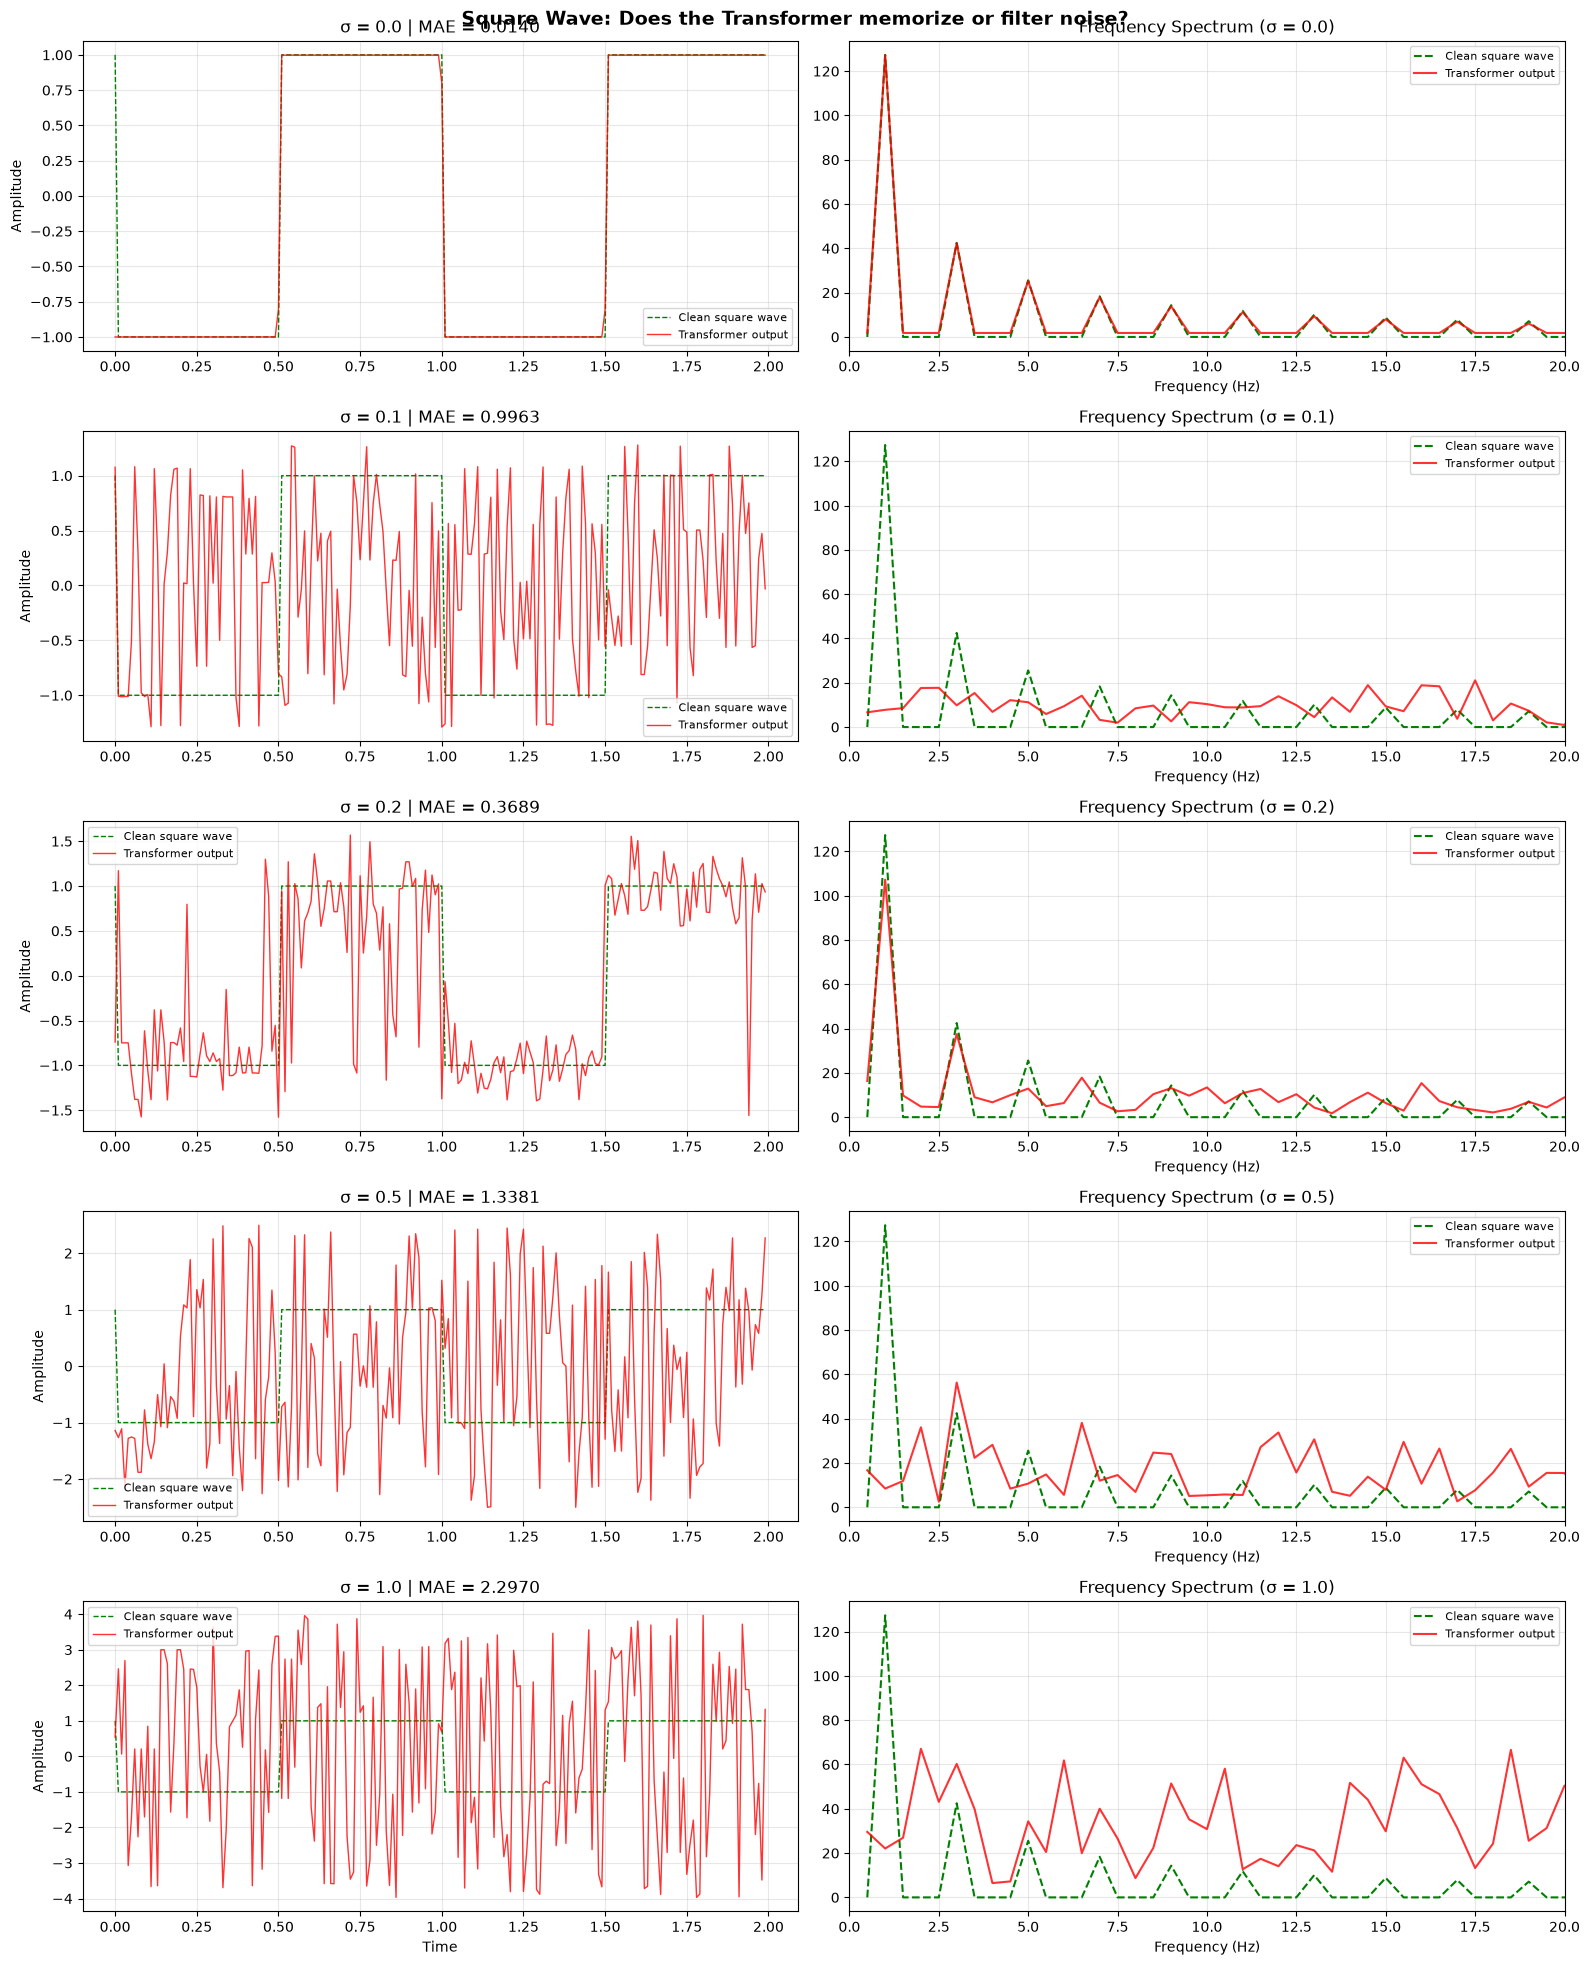

In [10]:
fig, axes = plt.subplots(len(noise_levels), 2, figsize=(16, 4 * len(noise_levels)))

for i, sigma in enumerate(noise_levels):
    r = results_square[sigma]
    generated = r['generated']
    y_true = r['y_true']
    t = np.arange(len(generated)) * 0.01

    ax = axes[i, 0]
    ax.plot(t[:len(y_true)], y_true[:len(t)], 'g--', linewidth=1, label='Clean square wave')
    ax.plot(t, generated[:len(t)], 'r-', linewidth=1, alpha=0.8, label='Transformer output')
    ax.set_title(f'σ = {sigma} | MAE = {r["mae"]:.4f}')
    ax.set_ylabel('Amplitude')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    ax = axes[i, 1]
    N = min(len(generated), len(y_true))
    freqs = np.fft.fftfreq(N, d=0.01)
    mask = freqs > 0
    spectrum_true = np.abs(np.fft.fft(y_true[:N]))
    spectrum_gen = np.abs(np.fft.fft(generated[:N]))
    ax.plot(freqs[mask], spectrum_true[mask], 'g--', label='Clean square wave')
    ax.plot(freqs[mask], spectrum_gen[mask], 'r-', alpha=0.8, label='Transformer output')
    ax.set_title(f'Frequency Spectrum (σ = {sigma})')
    ax.set_xlabel('Frequency (Hz)')
    ax.set_xlim(0, 20)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

axes[-1, 0].set_xlabel('Time')
plt.suptitle('Square Wave: Does the Transformer memorize or filter noise?', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.expanduser('~/research-project/plots/square_wave_comparison.png'), dpi=150)
plt.show()